# Catégorisez automatiquement des questions 

## Sommaire  

- Importation des bibliothèques
- Chargement des données
- Structure des données
- Fonctions de nettoyage
- Processus de nettoyage
    ○ Title
    ○ Body
    ○ Tags
- Fusion de Title et Body
- Enregistrement des données nettoyées


# Importation des bibliothèques

In [1]:
# Import des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

C:\Users\daims\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\daims\anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
C:\Users\daims\anaconda3\lib\site-packages\numpy\.libs\libopenblas.PYQHXLVVQ7VESDPUVUADXEVJOBGHJPAY.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
# Importation des librairies pour la prédiction

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn import decomposition
# from sklearn import preprocessing
from sklearn.cluster import KMeans

from sklearn.pipeline import Pipeline
from sklearn import linear_model
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics.cluster import adjusted_rand_score

# Visualisation des diagrammes
from sklearn import set_config


In [3]:
# # Permet d'élargir le notebook
# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:70% !important; }</style>"))

# Chargement des données

In [4]:
## Import des données brutes et analyse de leur architecture

path_local = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P5_' #
# path_cloud = 

data = pd.read_csv(path_local + r'\QueryResults_2012.csv',sep=",",low_memory=False)

# QueryResults
# QueryResults_2012

In [5]:
data

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount,CreationDate
0,The iOS Simulator deployment targets is set to...,<p>I'm getting this below warning message in m...,<ios><xcode><cocoapods><ios-simulator><google-...,54704207,307,305197,48,23,2019-02-15 07:05:56
1,Why isn't RDBMS Partition Tolerant in CAP Theo...,<p>Two points I don’t understand about RDBMS b...,<distributed-computing><rdbms><distributed-sys...,36404765,49,19219,19,4,2016-04-04 13:58:51
2,"Change the connection pool size for Python's ""...",<p>(edit: Perhaps I am wrong in what this err...,<python><multithreading><python-requests><requ...,18466079,62,33930,17,4,2013-08-27 12:55:44
3,What is the difference between triplestores an...,<p>There are triplestores (semantic databases)...,<graph><neo4j><semantics><graph-databases><tri...,18482663,23,8729,11,3,2013-08-28 08:16:28
4,How to use public and private key encryption t...,<p>I want to encrypt data using public/private...,<c#><encryption><cryptography><public-key-encr...,18485715,36,63153,14,2,2013-08-28 10:43:55
...,...,...,...,...,...,...,...,...,...
15885,Why is the Visual Studio 2015/2017/2019 Test R...,<p>UPDATE: Adding a 2019; the discovery/runner...,<.net><visual-studio><unit-testing><visual-stu...,35103781,201,201321,39,40,2016-01-30 15:55:13
15886,Failed to Read Artifact Descriptor: IntelliJ,<p>I am running into an issue with my Maven PO...,<java><maven><intellij-idea><apache-spark><apa...,35105667,29,46918,14,8,2016-01-30 18:49:23
15887,Ctrl Alt F8 disconnects displays?,<p>Learning debugging in PhpStorm and keep acc...,<windows><keyboard-shortcuts><windows-10><mult...,35108927,74,72289,12,7,2016-01-31 00:28:35
15888,How to use a class customization to resolve fi...,<p>I am trying to use Maven to generate JAXB f...,<java><spring><maven><jaxb><wsdl>,35108965,26,54218,11,8,2016-01-31 00:35:45


# Structure des données  

Le problème que l'on doit résoudre consiste à catégoriser un certains nombre de questions venant de la base de données sur une liste de tags connus. Les informations contenues dans les questions peuvent se retrouver dans les colonnes "Title" et "Body", les tags dans la colonne "Tags".  
A première vue, chacune de ces colonnes est composée de textes avec une structure particulière:
- Title: Essentiellement composé de mots avec des signes de ponctuatuins comme "?" pour introduire une question simplifiée.
- Body: Texte plus complet comprenant différentes balises entourées par des crochets, proche d'une page html. Chaque texte entourée par des balises comporte une information différente.
- Tags: Constitué que de balises avec une information différente.

Au vue de ces différentes structures de texte, on décide nettoyer ces colonnes séparément.

On va donc d'abord définir quelques fonctions de nettoyage basiques avant de réaliser concrètement le nettoyage.  

# Fonctions de nettoyage

In [46]:
# Tokenizer
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

def tokenizer_fct(sentence) :
    # remove or replace by empty or space char a specific symbol
    sentence_clean = sentence.replace('-', ' ').replace('/', ' ').replace('_', ' ').replace('<', ' ') \
    .replace('>', ' ').replace(':', ' ').replace('=', ' ').replace('.', ' ').replace("'", ' ').replace("\\", ' ')
    # Ajout de _, <, >, ', :, =, .
    word_tokens = word_tokenize(sentence_clean)
    return word_tokens

def digit_clean(list_words):
    # remove or replace by '' a char word from list_words only composed by digits
    filtered_w = [re.sub("^[0-9]+[0-9]$", "", w) for w in list_words] 
    return filtered_w
    
def body_html_tag_out(sentence):
    # remove or replace by empty or space char only < or >
    filtered_sentence = re.sub("<.+?>", " ", sentence)
    return filtered_sentence
    
def non_latin_char_clean(list_words):
    # replace all non latin char by empty char
    filtered_w = [re.sub("([^\x00-\x7F])+", "", w) for w in list_words]
    return filtered_w

    
# Stop words
from nltk.corpus import stopwords
stop_w = list(set(stopwords.words('english'))) + ['[', ']', ',', '.', ':', '?', '(', ')','','=',"'"]

def stop_word_filter_fct(list_words) :
    filtered_w = [w for w in list_words if not w in stop_w]
    filtered_w2 = [w for w in filtered_w if len(w) > 2]
    return filtered_w2

# lower case et alpha
def lower_start_fct(list_words) :
    lw = [w.lower() for w in list_words if (not w.startswith("@")) 
    #                                   and (not w.startswith("#"))
                                       and (not w.startswith("http"))]
    return lw

# Lemmatizer (base d'un mot)
from nltk.stem import WordNetLemmatizer

def lemma_fct(list_words) :
    lemmatizer = WordNetLemmatizer()
    lem_w = [lemmatizer.lemmatize(w) for w in list_words]
    return lem_w


In [47]:

# Fonction de préparation du texte pour le bag of words (Countvectorizer et Tf_idf, Word2Vec)
def transform_bow_fct(desc_text) :
    word_tokens = tokenizer_fct(desc_text)
    word_tokens_bis = non_latin_char_clean(word_tokens)
    lw = lower_start_fct(word_tokens_bis)
    sw = stop_word_filter_fct(lw)
    sw_bis = digit_clean(sw)
#     lw = lower_start_fct(sw_bis)
    # lem_w = lemma_fct(lw)    
    transf_desc_text = ' '.join(sw_bis)
    return transf_desc_text


# Fonction de préparation du texte pour le Deep learning (USE et BERT)
def transform_dl_fct(desc_text) :
    word_tokens = tokenizer_fct(desc_text)
#    sw = stop_word_filter_fct(word_tokens)
    lw = lower_start_fct(word_tokens)
    # lem_w = lemma_fct(lw)    
    transf_desc_text = ' '.join(lw)
    return transf_desc_text


In [48]:
# Tokenizer
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

def tokenizer_tags(sentence) :
    # print(sentence)
    sentence_clean = sentence.replace('<', ' ').replace('>', ' ').replace('-', ' ').replace(':', ' ')
    word_tokens = word_tokenize(sentence_clean.lower())
    word_tokens_bis = non_latin_char_clean(word_tokens)
    lw = lower_start_fct(word_tokens_bis)
    sw = stop_word_filter_fct(lw)
    sw_bis = digit_clean(sw)
#     lw = lower_start_fct(sw_bis)
    transf_desc_text = ' '.join(sw_bis)
    transf_desc_text_2 = transform_bow_fct(transf_desc_text)
    lw_bis = tokenizer_fct(transf_desc_text_2)
    word_tokens_sorted = sorted(set(lw_bis))
    return word_tokens_sorted


In [1]:
# Supprimer les mots comportant des voyelles identiques qui se suivent?
# Supprimer les mots comportant plus de 3 consonnes consécutives?


In [50]:
data_clean =pd.DataFrame()

# Processus de nettoyage

## Title  

In [51]:
data_clean['Title'] = data['Title'].apply(lambda x : transform_bow_fct(x))
data_clean

,Title
0,ios simulator deployment targets set range sup...
1,rdbms partition tolerant cap theorem available
2,change connection pool size python requests mo...
3,difference triplestores graph databases
4,use public private key encryption technique
...,...
15885,visual studio test runner discovering xunit...
15886,failed read artifact descriptor intellij
15887,ctrl alt disconnects displays
15888,use class customization resolve file generatin...


## Body

In [52]:
data_clean['Body'] = data['Body'].apply(lambda x : body_html_tag_out(x))
data_clean['Body']

0         I'm getting this below warning message in my ...
1         Two points I don’t understand about RDBMS bei...
2         (edit:  Perhaps I am wrong in what this error...
3         There are triplestores (semantic databases), ...
4         I want to encrypt data using public/private k...
                               ...                        
15885     UPDATE: Adding a 2019; the discovery/runner i...
15886     I am running into an issue with my Maven POM ...
15887     Learning debugging in PhpStorm and keep accid...
15888     I am trying to use Maven to generate JAXB fil...
15889      #include &lt;iostream&gt;\n#include &lt;map&...
Name: Body, Length: 15890, dtype: object

In [53]:
data_clean['Body'] = data_clean['Body'].apply(lambda x : transform_bow_fct(x))
data_clean['Body']

0        getting warning message xcode ios simulator de...
1        two points understand rdbms cap theorem says r...
2        edit perhaps wrong error means indicating conn...
3        triplestores semantic databases general purpos...
4        want encrypt data using public private key tec...
                               ...                        
15885    update adding  discovery runner integration me...
15886    running issue maven pom file unable find spark...
15887    learning debugging phpstorm keep accidentally ...
15888    trying use maven generate jaxb files used spri...
15889    include iostream include map include thread de...
Name: Body, Length: 15890, dtype: object

Evaluons rapidement à quel point la colonne "Body" a été traitée, en regardant quelques exemples:

In [54]:
data['Body'][15889]

'<pre><code>#include &lt;iostream&gt;\n#include &lt;map&gt;\n#include &lt;thread&gt;\n\n#define SIZE 1024\n#define AMOUNT 100000\n#define THREADS 4\n\nclass A\n{\nprivate:\n    char a[SIZE];\n};\n\nvoid test()\n{\n    std::cout &lt;&lt; "test start\\n";\n    std::map&lt;int, A*&gt; container;\n    for(int i=0; i&lt;AMOUNT; i++)\n    {\n        A* a = new A();\n        std::pair&lt;int, A*&gt;p = std::make_pair(i, a);\n        container.insert(p);\n    }\n\n    std::cout &lt;&lt; "test release\\n";\n    for(int i=0; i&lt;AMOUNT; i++)\n    {\n        auto iter = container.find(i);\n        delete iter-&gt;second;\n        container.erase(iter);\n    }\n    std::cout &lt;&lt; "test end\\n";\n}\n\nint main()\n{\n    std::thread ts[THREADS];\n    for(int i=0; i&lt;THREADS; i++)\n    {\n        ts[i] = std::thread(test);\n    }\n\n    for(std::thread&amp; x: ts)\n    {\n        x.join();\n    }\n\n    return 0;\n}\n</code></pre>\n\n<p>Above is a simple c++ code.</p>\n\n<p>compile with: <code

In [55]:
data_clean['Body'][15889]

'include iostream include map include thread define size  define amount  define threads class private char size void test std cout test start std map int container int amount i++ new std pair int std make pair container insert std cout test release int amount i++ auto iter container find delete iter second container erase iter std cout test end int main std thread threads int threads i++ std thread test std thread amp join return simple c++ code compile g++ pthread one one cpp wall std c++11 ldd one gots linux vdso 0x00007ffebafce000 libstdc++ usr lib x86 linux gnu libstdc++ 0x00007fb47352a000 libgcc lib x86 linux gnu libgcc 0x00007fb473313000 libpthread lib x86 linux gnu libpthread 0x00007fb4730f4000 libc lib x86 linux gnu libc 0x00007fb472d2a000 libm lib x86 linux gnu libm 0x00007fb472a22000 lib64 linux x86 0x00005654c5112000 run one every thing try static link g++ pthread one one cpp wall std c++11 static ldd one gots dynamic executable run thing goes wrong test start segmentation f

Ici, on constatae que certaines balises html comme "dependency, version, groupeid" qui étaient imbriquées dans d'autres balises ont été traitées comme du texte, ce qui rajoute de l'information qui n'est pas vraiement utile. Pour essayer de pallier à ce problème et traiter de manière plus efficace, on décide d'utiliser une bibliothèque spécialisée sur ce genre de traitement: BeautifulSoup.

In [56]:
from bs4 import BeautifulSoup
test_body = data['Body'][15889]
soup = BeautifulSoup(test_body)
print(soup.prettify())

<html>
 <body>
  <pre><code>#include &lt;iostream&gt;
#include &lt;map&gt;
#include &lt;thread&gt;

#define SIZE 1024
#define AMOUNT 100000
#define THREADS 4

class A
{
private:
    char a[SIZE];
};

void test()
{
    std::cout &lt;&lt; "test start\n";
    std::map&lt;int, A*&gt; container;
    for(int i=0; i&lt;AMOUNT; i++)
    {
        A* a = new A();
        std::pair&lt;int, A*&gt;p = std::make_pair(i, a);
        container.insert(p);
    }

    std::cout &lt;&lt; "test release\n";
    for(int i=0; i&lt;AMOUNT; i++)
    {
        auto iter = container.find(i);
        delete iter-&gt;second;
        container.erase(iter);
    }
    std::cout &lt;&lt; "test end\n";
}

int main()
{
    std::thread ts[THREADS];
    for(int i=0; i&lt;THREADS; i++)
    {
        ts[i] = std::thread(test);
    }

    for(std::thread&amp; x: ts)
    {
        x.join();
    }

    return 0;
}
</code></pre>
  <p>
   Above is a simple c++ code.
  </p>
  <p>
   compile with:
   <code>
    g++ -pthread -o one

Ici, on peut identifier plus facilement les différentes balises de type html. Certains symboles ne sont d'ailleurs pas tratés de la mêem façon (ex: \n pour les saut de lignes de codes).  
On décide d'utiliser un attribut de BeautiifulSoupp permettant de récupérer directement le texte à l'intérieur de ces balises:

In [57]:
text_2 = soup.text
text_2

'#include <iostream>\n#include <map>\n#include <thread>\n\n#define SIZE 1024\n#define AMOUNT 100000\n#define THREADS 4\n\nclass A\n{\nprivate:\n    char a[SIZE];\n};\n\nvoid test()\n{\n    std::cout << "test start\\n";\n    std::map<int, A*> container;\n    for(int i=0; i<AMOUNT; i++)\n    {\n        A* a = new A();\n        std::pair<int, A*>p = std::make_pair(i, a);\n        container.insert(p);\n    }\n\n    std::cout << "test release\\n";\n    for(int i=0; i<AMOUNT; i++)\n    {\n        auto iter = container.find(i);\n        delete iter->second;\n        container.erase(iter);\n    }\n    std::cout << "test end\\n";\n}\n\nint main()\n{\n    std::thread ts[THREADS];\n    for(int i=0; i<THREADS; i++)\n    {\n        ts[i] = std::thread(test);\n    }\n\n    for(std::thread& x: ts)\n    {\n        x.join();\n    }\n\n    return 0;\n}\n\nAbove is a simple c++ code.\ncompile with: g++ -pthread -o one one.cpp -Wall -std=c++11 -O3\nldd one, gots:\n    linux-vdso.so.1 =>  (0x00007ffebafce0

On récuoère effectivement le texte entre deux balises, mais les balises intérieures ont été vu comme du texte. On décide de réaliser une seconde fois:

In [58]:
soup2 = BeautifulSoup(text_2)
print(soup2.prettify())

<html>
 <body>
  <p>
   #include
   <iostream>
    #include
    <map>
     #include
     <thread>
      #define SIZE 1024
#define AMOUNT 100000
#define THREADS 4

class A
{
private:
    char a[SIZE];
};

void test()
{
    std::cout &lt;&lt; "test start\n";
    std::map
      <int a="">
       container;
    for(int i=0; i
       <amount a="" i="" std::pair="">
        p = std::make_pair(i, a);
        container.insert(p);
    }

    std::cout &lt;&lt; "test release\n";
    for(int i=0; i
        <amount auto="" delete="" i="" iter="container.find(i);" iter-="">
         second;
        container.erase(iter);
    }
    std::cout &lt;&lt; "test end\n";
}

int main()
{
    std::thread ts[THREADS];
    for(int i=0; i
         <threads a="" above="" c="" code.="" compile="" for="" g="" gots:="" i="" is="" ldd="" linux-vdso.so.1="" one="" one.cpp="" return="" simple="" std::thread="" ts="" with:="" x.join="" x:="">
          (0x00007ffebafce000)
    libstdc++.so.6 =&gt; /usr/lib/x86_64-linux

In [59]:
text_3 = soup2.text
text_3

'#include \n#include \n#include \n\n#define SIZE 1024\n#define AMOUNT 100000\n#define THREADS 4\n\nclass A\n{\nprivate:\n    char a[SIZE];\n};\n\nvoid test()\n{\n    std::cout << "test start\\n";\n    std::map container;\n    for(int i=0; ip = std::make_pair(i, a);\n        container.insert(p);\n    }\n\n    std::cout << "test release\\n";\n    for(int i=0; isecond;\n        container.erase(iter);\n    }\n    std::cout << "test end\\n";\n}\n\nint main()\n{\n    std::thread ts[THREADS];\n    for(int i=0; i  (0x00007ffebafce000)\n    libstdc++.so.6 => /usr/lib/x86_64-linux-gnu/libstdc++.so.6 (0x00007fb47352a000)\n    libgcc_s.so.1 => /lib/x86_64-linux-gnu/libgcc_s.so.1 (0x00007fb473313000)\n    libpthread.so.0 => /lib/x86_64-linux-gnu/libpthread.so.0 (0x00007fb4730f4000)\n    libc.so.6 => /lib/x86_64-linux-gnu/libc.so.6 (0x00007fb472d2a000)\n    libm.so.6 => /lib/x86_64-linux-gnu/libm.so.6 (0x00007fb472a22000)\n    /lib64/ld-linux-x86-64.so.2 (0x00005654c5112000)\n\nrun ./one, every thin

On a bien ici récupérer le texte qui nous intéresse. On pourrait pour terminer le lnettoyage, utiliser une des chaînes de fonctions crées en début du notebook. 

In [65]:
text_4 = transform_bow_fct(text_3)
text_4

'include include include define size  define amount  define threads class private char size void test std cout test start std map container int std make pair container insert std cout test release int isecond container erase iter std cout test end int main std thread threads int 0x00007ffebafce000 libstdc++ usr lib x86 linux gnu libstdc++ 0x00007fb47352a000 libgcc lib x86 linux gnu libgcc 0x00007fb473313000 libpthread lib x86 linux gnu libpthread 0x00007fb4730f4000 libc lib x86 linux gnu libc 0x00007fb472d2a000 libm lib x86 linux gnu libm 0x00007fb472a22000 lib64 linux x86 0x00005654c5112000 run one every thing try static link g++ pthread one one cpp wall std c++11 static ldd one gots dynamic executable run thing goes wrong test start segmentation fault core dumped compile gdb shows wang test gdb one gnu gdb ubuntu 1ubuntu2 copyright  free software foundation inc license gplv3+ gnu gpl version later free software free change redistribute warranty extent permitted law type show copying 

### Comparaison des méthodes de nettoyage du Body

In [102]:
# On tokenie les textes des deux méthodes précédentes

text_body_clean = data_clean['Body'][15889]
text_body_clean_tokenized = word_tokenize(text_body_clean )
text_4_tokenized = word_tokenize(text_4 )


In [103]:
freq_body_clean = nltk.FreqDist(text_body_clean_tokenized)
freq_text_4 = nltk.FreqDist(text_4_tokenized)
# freq_input

In [104]:
len(freq_body_clean)

158

In [105]:
len(freq_text_4)

142

Ici, la méthode utilisant BeautifulSoup d'abord semble légèrement réduire plus le nombre de mot que la méthode brut d'effacement des tags html pour cet exemple. En supposant qu'on puisse généraliser ce phénomène à totu le corpus de notre dataframe, on choisit par la suite cette seconde méthode pour nettoyer la colonne 'Body'. 

Pour s'assurer que l'on prend bien en compte le nombre de balises insérées dans d'autres balises, on pourrait calculer le nombre totale de balises enfants, et relancer la capture de texte hors des balises jusqu'à ce qu'il n'y ait plus de balises imbriquées.  
BeautifulSoup possède des fonctions et attributs pour évaluer ce nombre. On décide de créer la fonction suivante:

In [106]:
def delete_tag_cv(sentence):
    #Récupère le texte à l'intérieur de plusierus tags imbriquées
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(sentence)
    list_tag =  [tag.name for tag in soup.find_all()]
    list_tag_prec = list_tag + list_tag
    while not(len(list_tag) == len(list_tag_prec)):
        # la dimension de list_tag ne tombe jamais à zéro, donc on regarde lorsqu'elle converge vers une valeure fixe
        list_tag_prec = list_tag.copy()
        print("list_tag size is: " + str(len(list_tag)))
        sentence = soup.text
        soup = BeautifulSoup(sentence)
        list_tag =  [tag.name for tag in soup.find_all()]
#         list_tag = child_tag_list(soup)
        print(str(list_tag))
#         print("list_tag size is: " + str(len(list_tag)))
#         print(str(sentence))
    return sentence

In [107]:
data_clean['Body_soup'] = data['Body'].apply(lambda x : delete_tag_cv(x))
data_clean['Body_soup']

list_tag size is: 18
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 9
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 4
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 8
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 22
['html', 'body', 'p', 'module']
list_tag size is: 4
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 57
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 

list_tag size is: 8
['html', 'body', 'p', 'typename', 'size_t', 'base::get_data']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 42
['html', 'body', 'p', 'actionresult', 'etdsuser', 'etdsuser']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 30
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 92
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 12
['html', 'body', 'p', 'string', 'string']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 7
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 12
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 54
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag siz

list_tag size is: 10
['html', 'body', 'p', 'top', 'main']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 18
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 50
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 34
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 7
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 22
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 34
['html', 'body', 'p', 'offset', 'datatype']
list_tag size is: 5
['html', 'b

list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 15
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 9
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 41
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 13
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 15
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 12
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 9
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p', 'stdio.h', 'stdlib.h', 'unistd.h', 'string.h', 'sys', 'sys', 'netine

list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 33
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 4
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 27
['html', 'body', 'p', 'const', 'eigen::matrixxd', 'const', 'const', 'const', 'eigen::matrixxd', 'eigen::matrixxd', 'const', 'const', 'eigen::matrixxd', 'eigen::matrixxd']
list_tag size is: 14
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 30
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 46
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 34
['html', 'body', 'p']
li

...

['html', 'body', 'p']
list_tag size is: 8
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 20
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 29
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 9
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 24
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 7
['html', 'body', 'p', 'div', 'img']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 13
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 17
['html', 'body', 'p']
list_tag size is: 3
['html', 'bod

list_tag size is: 20
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 21
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 17
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 14
['html', 'body', 'p', 'object', 'object', 'object', 'object']
list_tag size is: 7
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 7
['html', 'body', 'p', 'iframe', 'frameset', 'frame', 'frame', 'div', 'div', 'div', 'ul', 'li', 'li']
list_tag size is: 13
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 7
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 121
['html', 'body', 'p', 'string', 'manifest', 'uses-sdk', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', 'uses-permission', '

list_tag size is: 19
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 14
['html', 'body', 'p', 't', 'databuffer']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 13
['html', 'body', 'p', 'ul', 'li', 'li', 'ul', 'li', 'li', 'li', 'ul', 'li', 'li']
list_tag size is: 30
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 17
['html', 'body', 'p', 'my-toolbar', 'my-navbar']
list_tag size is: 5
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 19
['html', 'body', 'p', 'div', 'div', 'div', 'ul', 'li', 'a', 'li', 'a', 'li', 'a', 'li', 'a', 'div', 'div', 'div', 'button', 'div']
list_tag size is: 20
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 46
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p', 'string', 'string']


list_tag size is: 7
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 13
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 8
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 9
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 78
['html', 'body', 'p', 'canvas']
list_tag size is: 4
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 4
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 11
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 10
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 6
['html', 'body', 'p']
list_tag size is: 3
['html', 'body', 'p']
list_tag size is: 14
['html', 'body', 'p', 'h2', 'h2', 'scrip

0        I'm getting this below warning message in my X...
1        Two points I don’t understand about RDBMS bein...
2        (edit:  Perhaps I am wrong in what this error ...
3        There are triplestores (semantic databases), a...
4        I want to encrypt data using public/private ke...
                               ...                        
15885    UPDATE: Adding a 2019; the discovery/runner in...
15886    I am running into an issue with my Maven POM f...
15887    Learning debugging in PhpStorm and keep accide...
15888    I am trying to use Maven to generate JAXB file...
15889    #include \n#include \n#include \n\n#define SIZ...
Name: Body_soup, Length: 15890, dtype: object

In [108]:
data_clean['Body_soup'] = data_clean['Body_soup'].apply(lambda x : transform_bow_fct(x))
data_clean['Body_soup']

0        getting warning message xcode ios simulator de...
1        two points understand rdbms cap theorem says r...
2        edit perhaps wrong error means indicating conn...
3        triplestores semantic databases general purpos...
4        want encrypt data using public private key tec...
                               ...                        
15885    update adding  discovery runner integration me...
15886    running issue maven pom file unable find spark...
15887    learning debugging phpstorm keep accidentally ...
15888    trying use maven generate jaxb files used spri...
15889    include include include define size  define am...
Name: Body_soup, Length: 15890, dtype: object

## Tags  
On utilise ici la fonction que l'on a créé pour retirer les crochets dees balises.

In [109]:
data_clean['Tags'] = data['Tags'].apply(lambda x : tokenizer_tags(x))
data_clean['Tags']

0        [cocoapods, fabric, google, ios, simulator, xc...
1        [cap, computing, distributed, nosql, rdbms, sy...
2        [connection, multithreading, pooling, python, ...
3        [databases, graph, neo4j, semantics, triplestore]
4         [cryptography, encryption, key, private, public]
                               ...                        
15885         [net, studio, testing, unit, visual, xunit2]
15886    [apache, idea, intellij, java, kafka, maven, s...
15887    [card, keyboard, monitors, multiple, shortcuts...
15888                    [java, jaxb, maven, spring, wsdl]
15889                   [boost, c++, c++11, gcc, pthreads]
Name: Tags, Length: 15890, dtype: object

Evaluons le nombre de tags ou labels uniques que l'on récupère à l'issue de ce prétraitement: 

In [110]:
# list_tags_total = []
# list_tags_total = [ list_tags_total.append(data_clean['Tags'].iloc[i]) for i in range(data_clean.shape[0])]

In [111]:
# list_tags_total = []
# list_tags_total = [ list_tags_total.extend(data_clean['Tags'].iloc[i]) for i in range(data_clean.shape[0])]

In [112]:
# On crée un document unique comprenant une liste de tout les mots du corpus.
list_tags_total = []
for i in range(data_clean.shape[0]):
    list_tags_total.extend(data_clean['Tags'].iloc[i])

In [113]:
list_tags_total

['cocoapods',
 'fabric',
 'google',
 'ios',
 'simulator',
 'xcode',
 'cap',
 'computing',
 'distributed',
 'nosql',
 'rdbms',
 'system',
 'theorem',
 'connection',
 'multithreading',
 'pooling',
 'python',
 'request',
 'requests',
 'databases',
 'graph',
 'neo4j',
 'semantics',
 'triplestore',
 'cryptography',
 'encryption',
 'key',
 'private',
 'public',
 'flask',
 'python',
 'rest',
 'wsgi',
 'ffmpeg',
 'mp4',
 'php',
 'processing',
 'video',
 'java',
 'oauth',
 'security',
 'spring',
 'apache2',
 'linux',
 'subsystem',
 'windows',
 'iconbitmap',
 'python',
 'tkinter',
 'windows',
 'android',
 'bitmap',
 'compression',
 'image',
 'jpeg',
 'asp',
 'core',
 'entity',
 'framework',
 'mvc',
 'net',
 'sqlite',
 'agnostic',
 'architecture',
 'cache',
 'concurrency',
 'cpu',
 'language',
 'android',
 'gradle',
 'installation',
 'java',
 'maven',
 'concatenation',
 'efficiency',
 'pandas',
 'performance',
 'processing',
 'python',
 'cell',
 'cocoa',
 'event',
 'mouseclick',
 'nstableview',
 

On utilise la bibliiothèque nltk pour récupérer de manière unique chaque mot, et compter leur fréquence d'apparition.

In [114]:
freq_tags = nltk.FreqDist(list_tags_total)
freq_tags

FreqDist({'python': 2253, 'javascript': 1801, 'ios': 1711, 'java': 1711, 'android': 1519, 'net': 1083, 'c++': 891, 'html': 724, 'asp': 692, 'objective': 660, ...})

In [115]:
len(freq_tags)

6832

On peu noter deux choses suite à ces résultats:
- Certains tags sont similaires et donc nécessitent d'être mieux nettoyés --> exemple: c++ et c++11, ios  et ios7....
- On a plus de 6000 tags uniques, ce qui est assez élevé. On aimerait se limiter à 100 tags pour notre étude.  

On va créer une fonction permettant de supprimer les caratères numériques à la fin des mots, pour réduire le nombre de tags similaires. On va ensuite sélectionné les 100 tags les plus fréquents du corpus.

In [116]:
def suffix_digit_clean(list_words):
    #remove or replace by '' a char word from list_words only composed by digits
    filtered_w = [re.sub(r'\d+$', "", w) for w in list_words] # ajout d'un "+"
    return filtered_w

In [117]:
data_clean['Tags'] = data_clean['Tags'].apply(lambda x : suffix_digit_clean(x))
data_clean['Tags']

0        [cocoapods, fabric, google, ios, simulator, xc...
1        [cap, computing, distributed, nosql, rdbms, sy...
2        [connection, multithreading, pooling, python, ...
3        [databases, graph, neo4j, semantics, triplestore]
4         [cryptography, encryption, key, private, public]
                               ...                        
15885          [net, studio, testing, unit, visual, xunit]
15886    [apache, idea, intellij, java, kafka, maven, s...
15887    [card, keyboard, monitors, multiple, shortcuts...
15888                    [java, jaxb, maven, spring, wsdl]
15889                     [boost, c++, c++, gcc, pthreads]
Name: Tags, Length: 15890, dtype: object

On recalcule la fréquence des tags:

In [118]:
# On crée un document unique comprenant une liste de tout les mots du corpus.
list_tags_total = []
for i in range(data_clean.shape[0]):
    list_tags_total.extend(data_clean['Tags'].iloc[i])

In [119]:
freq_tags = nltk.FreqDist(list_tags_total)
freq_tags

FreqDist({'python': 2253, 'ios': 2183, 'javascript': 1801, 'java': 1720, 'android': 1519, 'c++': 1238, 'net': 1083, 'html': 789, 'asp': 692, 'swift': 688, ...})

In [120]:
len(freq_tags)

6661

On trace la fréquence des 100 premieris tags:

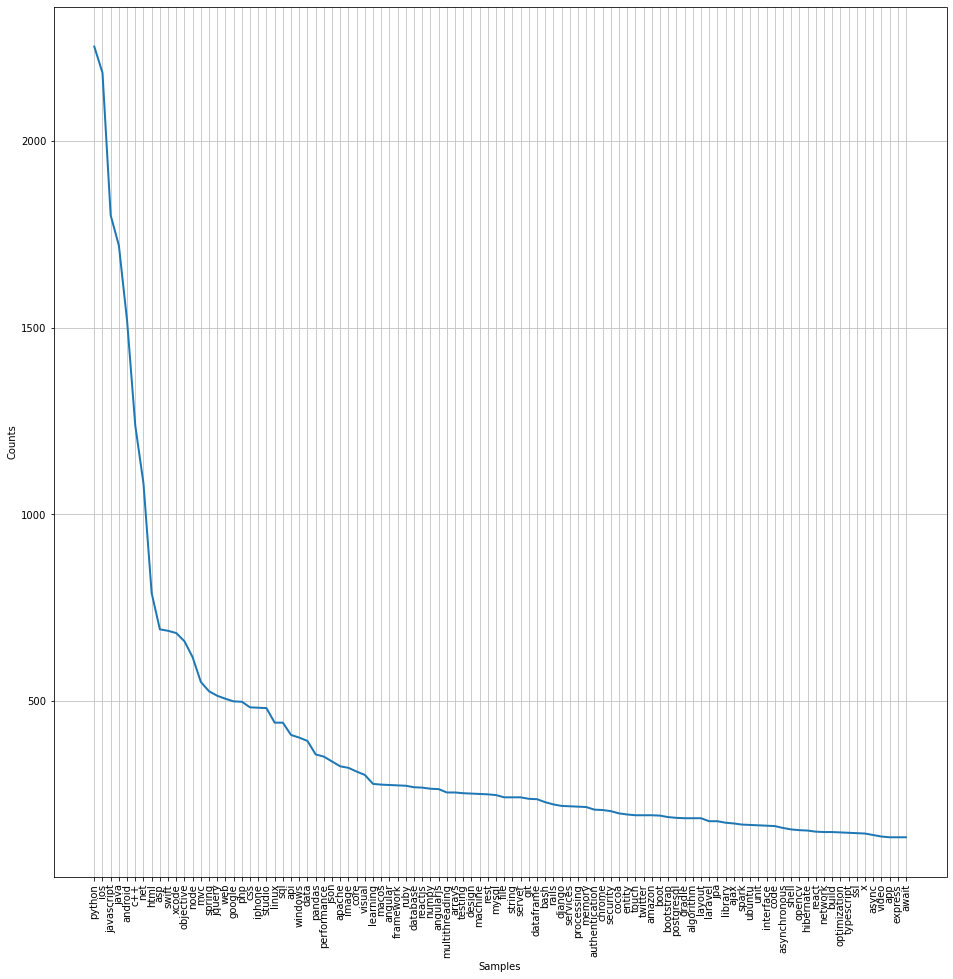

In [121]:
# Tracé des 100 mots les plus fréquents
plt.figure(figsize=(16,16))
freq_tags.plot(100)
plt.show()

In [122]:
# Tracés des 100 derniers mots
for x in list(reversed(freq_tags))[0:1000]:
#     print (x)
    print ("{}, {} ".format(x,  freq_tags[x]))

healthkit, 1 
preferencescreen, 1 
softmax, 1 
uitextposition, 1 
ctest, 1 
metacircular, 1 
community, 1 
genfromtxt, 1 
aggregateroot, 1 
saturation, 1 
distortion, 1 
spacy, 1 
chips, 1 
firebreath, 1 
groovyshell, 1 
turi, 1 
changedetection, 1 
xsrf, 1 
pexpect, 1 
writing, 1 
rubymotion, 1 
localizable, 1 
gcm, 1 
folium, 1 
inputaccessoryview, 1 
gganimate, 1 
mopub, 1 
elk, 1 
reactstrap, 1 
woff, 2 
gatekeeper, 1 
shinydashboard, 1 
runsettings, 1 
coded, 1 
kable, 1 
sslerrorhandler, 1 
nslayoutmanager, 1 
uploader, 1 
multifile, 1 
anemic, 1 
qtwebkit, 1 
qtwebengine, 1 
cas, 1 
kapt, 1 
subnet, 1 
jmod, 1 
pushsharp, 1 
matches, 1 
springjunit4classrunner, 1 
xquartz, 1 
whoops, 1 
aurora, 1 
viewholder, 1 
sat, 1 
spss, 1 
nbconvert, 1 
avplayerlayer, 1 
avcomposition, 1 
mailgun, 1 
streambuf, 1 
tokyo, 1 
ecma, 1 
validationattribute, 1 
jdo, 1 
neighbours, 1 
finally, 1 
getelementbyid, 1 
frameset, 1 
qlikview, 1 
qliksense, 1 
accountmanager, 1 
annotate, 1 
places, 1

On filtre nos tags pour garder ceux compris dans la liste des 100 tags les plus fréquents.

In [123]:
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

In [124]:
data_clean['Tags_filtered'] = [ intersection(value,list(freq_tags)[0:100]) for value in data_clean['Tags']]
data_clean['Tags_filtered']

0                        [google, ios, xcode]
1                                          []
2                    [multithreading, python]
3                                          []
4                                          []
                         ...                 
15885    [net, studio, testing, unit, visual]
15886                   [apache, java, spark]
15887                        [video, windows]
15888                          [java, spring]
15889                              [c++, c++]
Name: Tags_filtered, Length: 15890, dtype: object

Evaluons la proportion de lignes contenant des tags de notre liste de tags réduite aux 100 tags les plus fréquents.

In [125]:
data_clean['Tags_filtered_len'] = [ len(value) for value in data_clean['Tags_filtered']]
data_clean['Tags_filtered_len']

0        3
1        0
2        2
3        0
4        0
        ..
15885    5
15886    3
15887    2
15888    2
15889    2
Name: Tags_filtered_len, Length: 15890, dtype: int64

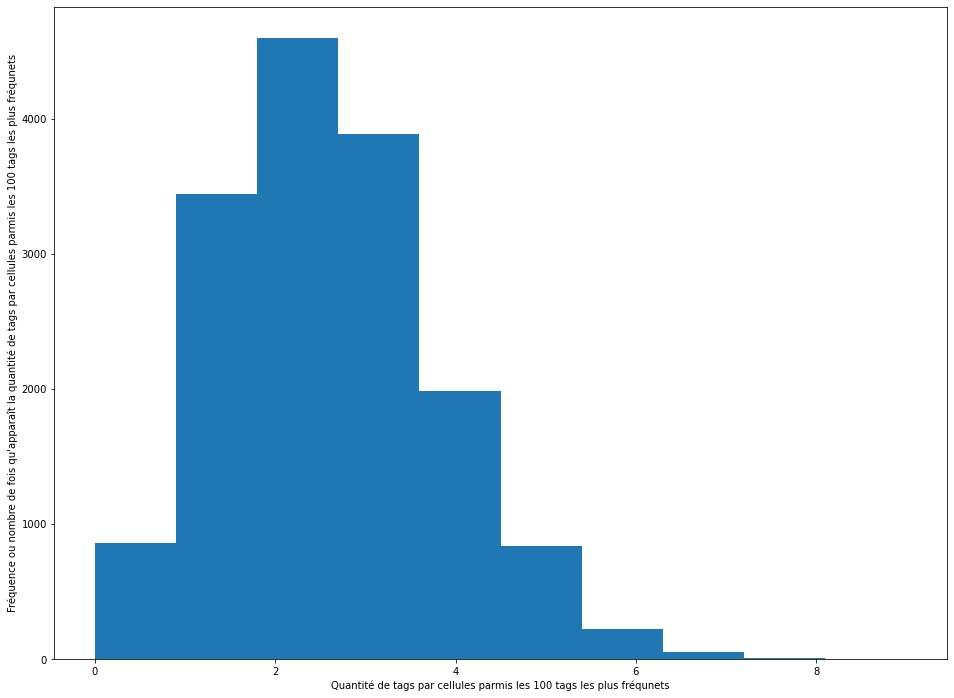

In [126]:
data_clean['Tags_filtered_len'].plot.hist(figsize=(16,12))
plt.ylabel("Fréquence ou nombre de fois qu'apparaît la quantité de tags par cellules parmis les 100 tags les plus fréqunets")
plt.xlabel("Quantité de tags par cellules parmis les 100 tags les plus fréqunets")
plt.show()

On constate que près de 1000 lignes sur les 15889 ne comportent pas de tags parmi les 100 plus fréquents. On a le choix entre les garder mais lors de l'apprentissage supervisé des lignes, ces lignes seront considérées comme un groupe à part dont on ne pourra pas donner de sens commun, ou alors les suprimer pour éviter de fausser l'apprentissage et ne garder que des lignes labellisées.

#  Fusion de Title et Body

In [127]:
data_clean['text_input'] = data_clean['Title'] + data_clean['Body_soup']
data_clean['text_input']

0        ios simulator deployment targets set range sup...
1        rdbms partition tolerant cap theorem available...
2        change connection pool size python requests mo...
3        difference triplestores graph databasestriples...
4        use public private key encryption techniquewan...
                               ...                        
15885    visual studio    test runner discovering xunit...
15886    failed read artifact descriptor intellijrunnin...
15887    ctrl alt disconnects displayslearning debuggin...
15888    use class customization resolve file generatin...
15889    g++ static link pthread cause segmentation fau...
Name: text_input, Length: 15890, dtype: object

# Enregistrement des données nettoyées 
## Enregistrement des colonnes d'entrées et de sorties sous formes de fichier csv.

In [128]:
# saving the dataframe
data_clean[['text_input','Tags_filtered']].to_csv('D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P5_\\data_clean.csv', sep=',', index=False)